# 반도체 공정 스케줄링 시뮬레이션 결과

## 환경 설정

In [1]:
import os
import simpy
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans KR'

# .env 파일의 환경 변수 로드
load_dotenv()

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')

## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler, Job
from simulation.planned_scheduler import PlannedScheduler as Scheduler
# 향후 알고리즘 모듈 추가 예정
# from algorithms.genetic import GeneticScheduler
# from algorithms.rule_based import RuleBasedScheduler
from algorithms.rule_based.stage1_gurobi import FJSPGurobiScheduler

## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)

data = data_loader.load_all_data()

print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")
print(f"Machine Failures: {len(data['machine_failure'])} 개")
print(f"Setup Times: {len(data['setup_times'])} 개")
print(f"Operation-Machine Map: {len(data['operation_machine_map'])} 개")


qtime_constraints = pd.read_csv(os.path.join(BASE_DATA_PATH, "qtime_constraints.csv"))

optimizer = FJSPGurobiScheduler(
    jobs_df=data["jobs"],
    operations_df=data["operations"],
    machines_df=data["machines"],
    op_machine_df=data["operation_machine_map"],
    qtime_constraints_df=qtime_constraints,
    setup_times_df=data["setup_times"],
    qtime_weight=100.0,
    time_limit=300.0,
)

stage1_result = optimizer.solve()
stage1_result.to_csv("stage1_schedule_result.csv", index=False)
stage1_result

데이터 개요
Jobs: 10 개
Operations: 35 개
Machines: 8 개
Machine Failures: 8 개
Setup Times: 12 개
Operation-Machine Map: 95 개
Set parameter Username
Set parameter LicenseID to value 2773517
Academic license - for non-commercial use only - expires 2027-02-02
Set parameter TimeLimit to value 300
Set parameter LogToConsole to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 2865 rows, 1271 columns and 11265 nonzeros (Min)
Model fingerprint: 0x527bdb38
Model has 26 linear objective coefficients
Variable types: 96 continuous, 1175 integer (1175 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+03]

Presolve removed 620 rows and 571 columns
Presolve time: 0.03s
Presolved: 2245 rows, 700 c

,job_id,op_id,op_seq,machine_id,start_time,end_time
0,J1,J1_O1,1,M2,0.0,8.0
1,J1,J1_O2,2,M5,8.0,23.0
2,J1,J1_O3,3,M2,23.0,34.0
3,J1,J1_O4,4,M8,34.0,43.0
4,J10,J10_O1,1,M3,30.0,42.0
5,J10,J10_O2,2,M5,55.0,67.0
6,J10,J10_O3,3,M6,67.0,82.0
7,J2,J2_O1,1,M1,0.0,8.0
8,J2,J2_O2,2,M4,8.0,23.0
9,J2,J2_O3,3,M6,23.0,31.0


## 시뮬레이션 실행

In [ ]:
# SimPy 환경 생성
env = simpy.Environment()

# 이벤트 로거 생성
event_logger = EventLogger(env)

# 스케줄러 생성
scheduler = Scheduler(
    env=env,
    machine_df=data["machines"],
    operations_df=data["operations"],
    machine_failure_df=data["machine_failure"],
    setup_times_df=data["setup_times"],
    op_machine_df=data["operation_machine_map"],
    planned_schedule_df=stage1_result,
    event_logger=event_logger,
    enable_failure=False,
)

TypeError: PlannedScheduler.__init__() missing 1 required positional argument: 'planned_schedule_df'

## 작업 생성

In [ ]:
jobs = []
for _, job_info in data['jobs'].iterrows():
    # 해당 작업의 operation 정보 가져오기
    job_operations = data['operations'].loc[
        data['operations']['job_id'] == job_info['job_id'],
        ['op_id', 'op_seq', 'qtime']
    ].sort_values('op_seq')
    
    # Job 인스턴스 생성
    job = Job(
        env=env,
        job_info=job_info.to_dict(),
        op_info=job_operations,
        scheduler=scheduler,
        event_logger=event_logger
    )
    jobs.append(job)

## 시뮬레이션 실행

In [ ]:
env.run(until=env.all_of(job.process for job in jobs))
fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f"반도체 공정 간트 차트 (Simulation Time: {round(env.now, 3)})")
fig.show()

## 시뮬레이션 KPI 및 통계

### 작업별 통계

In [ ]:
df_logs = pd.DataFrame(event_logger.logs)
completed_cnt = 0
completed_in_due_date = 0
total_qtime_violation = 0.0
for job in jobs:
    print(f"Job ID: {job.id}, QTime Violation: {round(job.calculate_qtime_over(env.now), 3)}")
    completed_cnt += int(job.is_completed)
    completed_in_due_date = int(job.is_in_due_date())
    total_qtime_violation += job.total_qtime_over
print(f"총 작업 수: {len(jobs)}\n완료된 작업 수: {completed_cnt}\n기한 안에 완료된 작업 수: {completed_in_due_date}\n총 QTime 위반 시간: {round(total_qtime_violation, 3)}")
# 향후 결과 분석 기능 추가
# - 평균 대기 시간
# - 장비 가동률

Job ID: J1, QTime Violation: 8.0
Job ID: J2, QTime Violation: 0.0
Job ID: J3, QTime Violation: 0.0
Job ID: J4, QTime Violation: 0.0
Job ID: J5, QTime Violation: 0.0
Job ID: J6, QTime Violation: 0.0
Job ID: J7, QTime Violation: 4.545
Job ID: J8, QTime Violation: 0.0
Job ID: J9, QTime Violation: 17.498
Job ID: J10, QTime Violation: 6.229
총 작업 수: 10
완료된 작업 수: 2
기한 안에 완료된 작업 수: 0
총 QTime 위반 시간: 36.273


,waiting,setup,working,job_type
id,,,,
J1,15.000,5.0,37.194,P1
J3,5.000,7.0,42.506,P1
J5,1.000,0.0,0.455,P1
J7,18.000,0.0,25.426,P1
J9,37.953,7.0,48.363,P1
J10,36.426,0.0,51.722,P2
J2,0.000,0.0,33.000,P2
J4,5.000,5.0,25.953,P2
J6,5.000,4.0,10.197,P2


findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
/Users/miles/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/miles/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
/Users/miles/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE 

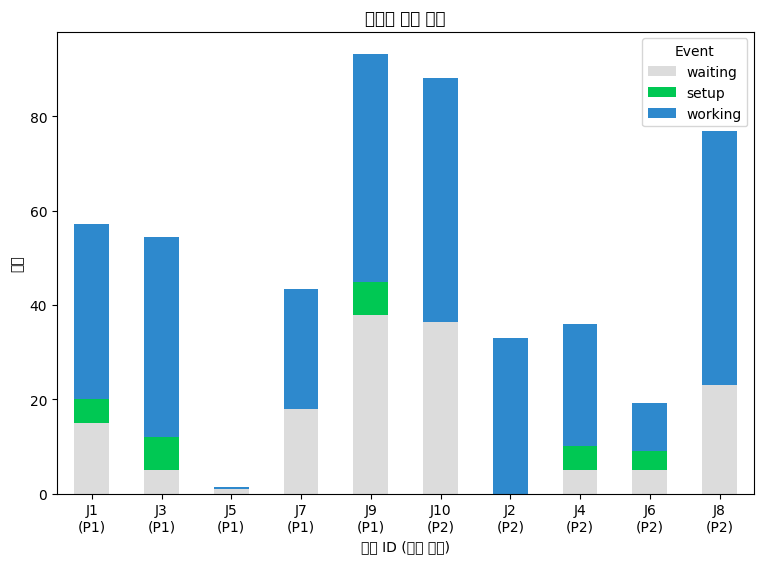

In [ ]:
job_info = df_logs[df_logs['resource'] == 'job']
job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
job_info = job_info.groupby(['id', 'event'])['duration'].sum().reset_index(['id', 'event'], drop=False)
job_stacked = job_info.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked = job_stacked.reindex(columns=['waiting', 'setup', 'working'], fill_value=0)
job_type_map = data['jobs'].set_index('job_id')['job_type']
job_stacked = job_stacked.join(job_type_map).sort_values('job_type')
display(job_stacked)
job_stacked.index = [f"{i}\n({t})" for i, t in zip(job_stacked.index, job_stacked['job_type'])]
job_stacked.plot(kind='bar', stacked=True, figsize=(9, 6), color={
    "waiting": '#DCDCDC',
    "setup": '#00C853',
    "working": '#2E89CD'
})
plt.title("작업별 소요 시간")
plt.xlabel("작업 ID (작업 유형)")
plt.ylabel("시간")
plt.xticks(rotation=0)
plt.legend(title="Event")
plt.show()

### 공정별 설비 활용률

,utilization,group
id,,
M1,0.354654,G1
M2,0.524023,G1
M3,0.314390,G1
M4,0.527628,G2
M5,0.498269,G2
M6,0.278916,G3
M7,0.200494,G3
M8,0.080771,G3


/var/folders/fb/s0q1ctcn3j9g58_h29cms2vc0000gn/T/ipykernel_59235/3043275448.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=machine_utilization, x='group', y='utilization',
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
/Users/miles/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/miles/Libr

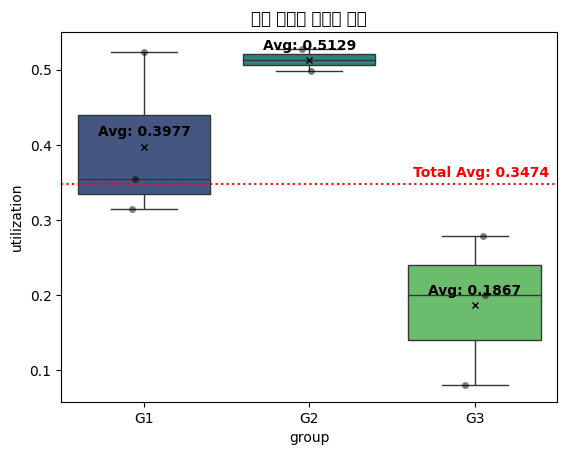

In [ ]:
machine_info = df_logs[df_logs['resource'] == 'machine']
machine_info['utilization'] = machine_info['finish'] - machine_info['start']
machine_utilization = pd.DataFrame(machine_info[machine_info['event'] == 'working'].groupby('id')['utilization'].sum() / env.now)
machine_utilization['group'] = data['machines'].set_index('machine_id').loc[machine_utilization.index]['machine_group']
display(machine_utilization)
group_means = machine_utilization.groupby('group')['utilization'].mean()
total_mean = machine_utilization['utilization'].mean()
sns.boxplot(data=machine_utilization, x='group', y='utilization', 
            palette='viridis', showmeans=True,
            meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"5"})
sns.stripplot(data=machine_utilization, x='group', y='utilization', 
              color='black', alpha=0.5, jitter=True)
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    plt.text(i, mean_val + 0.01, f'Avg: {mean_val:.4f}', 
             ha='center', va='bottom', color='black', fontweight='bold')
plt.text(len(group_means)-0.55, total_mean + 0.01, f'Total Avg: {total_mean:.4f}', color='red', fontweight='bold', ha='right')
plt.axhline(total_mean, color='red', linestyle=':')
plt.title("공정 그룹별 가동률 분포")
plt.show()